In [1]:
import os
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import nibabel as nib

from tqdm.auto import tqdm

from scipy.signal import resample

from nilearn import datasets
from nilearn.image import (
    clean_img,
    smooth_img,
    resample_to_img,
)

from nilearn.maskers import NiftiLabelsMasker

warnings.filterwarnings("ignore")

In [5]:
##############################################
# DATASET ROOT
##############################################

DATA_ROOT = Path(
    "/teamspace/studios/this_studio/BOLDMoments"
)

##############################################
# OUTPUT DIRECTORY
##############################################

OUTPUT_ROOT = Path(
    "/teamspace/studios/this_studio/processed_boldmoments"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

##############################################
# PREPROCESSING
##############################################

TARGET_TR = 1.0

SMOOTH_FWHM = 4.0

HEMODYNAMIC_DELAY_SEC = 5.0

##############################################
# TIAN ATLAS
##############################################

TIAN_PATH = Path(
    "~/subcortex/Group-Parcellation/3T/Subcortex-Only/Tian_Subcortex_S2_3T.nii"
).expanduser()

In [3]:
print("="*60)
print("Loading Schaefer Atlas...")
print("="*60)

atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=1000,
    yeo_networks=17,
    resolution_mm=2
)

cortical_img = nib.load(
    atlas.maps
)

print("Loaded Successfully")
print(atlas.maps)

Loading Schaefer Atlas...


[fetch_atlas_schaefer_2018] Added README.md to /teamspace/studios/this_studio/nilearn_data

[fetch_atlas_schaefer_2018] Dataset created in /teamspace/studios/this_studio/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_1000Parcels_17Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_1000Parcels_17Networks_order_FSLMNI152_2m
m.nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

Loaded Successfully
/teamspace/studios/this_studio/nilearn_data/schaefer_2018/Schaefer2018_1000Parcels_17Networks_order_FSLMNI152_2mm.nii.gz


In [6]:
print("="*60)
print("Loading Tian Atlas...")
print("="*60)

subcortical_img = nib.load(
    str(TIAN_PATH)
)

print("Loaded Successfully")
print(TIAN_PATH)

Loading Tian Atlas...
Loaded Successfully
/teamspace/studios/this_studio/subcortex/Group-Parcellation/3T/Subcortex-Only/Tian_Subcortex_S2_3T.nii


In [11]:
bold_files = sorted(

    list(

        DATA_ROOT.glob(
            "sub-*/ses-*/func/*bold.nii"
        )

    )

)

if len(bold_files) == 0:

    bold_files = sorted(

        list(

            DATA_ROOT.glob(
                "sub-*/ses-*/func/*bold.nii.gz"
            )

        )

    )

print("="*60)

print(
    f"Found {len(bold_files)} BOLD Runs"
)

print("="*60)

for f in bold_files[:10]:
    print(f)

Found 620 BOLD Runs
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-1_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-2_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-3_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-4_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-5_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-1_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-2_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-3_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-

In [12]:
subjects = sorted(
    list(
        DATA_ROOT.glob("sub-*")
    )
)

sessions = sorted(
    list(
        DATA_ROOT.glob("sub-*/ses-*")
    )
)

print("="*60)

print(
    "Subjects :",
    len(subjects)
)

print(
    "Sessions :",
    len(sessions)
)

print(
    "Runs :",
    len(bold_files)
)

print("="*60)

Subjects : 10
Sessions : 50
Runs : 620


In [13]:
processed_dir = OUTPUT_ROOT

processed_dir.mkdir(
    exist_ok=True
)

print(processed_dir)

/teamspace/studios/this_studio/processed_boldmoments


In [9]:
from pathlib import Path

# CHANGE THIS TO YOUR DATASET LOCATION
DATA_ROOT = Path.home() / "datasets" / "BOLDMoments"

print("Dataset root:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

bold_files = sorted(list(DATA_ROOT.rglob("*bold.nii")))

if len(bold_files) == 0:
    bold_files = sorted(list(DATA_ROOT.rglob("*bold.nii.gz")))

print(f"\nFound {len(bold_files)} BOLD files")

for f in bold_files[:10]:
    print(f)

Dataset root: /teamspace/studios/this_studio/datasets/BOLDMoments
Exists: True

Found 620 BOLD files
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-1_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-2_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-3_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-4_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-5_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-1_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-2_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-3_bol

In [18]:
from nilearn.image import clean_img, smooth_img
from nilearn.maskers import NiftiLabelsMasker
from scipy.signal import resample
import nibabel as nib
import numpy as np


def preprocess_bold(fmri_path):

    print("\n====================================================")
    print("Processing:")
    print(fmri_path)

    img = nib.load(str(fmri_path))

    tr = img.header.get_zooms()[3]

    print("Original Shape:", img.shape)
    print("TR:", tr)

    ############################################################
    # Cleaning
    ############################################################

    cleaned = clean_img(
        img,
        detrend=True,
        standardize="zscore_sample",
        low_pass=None,
        high_pass=None,
        t_r=tr
    )

    ############################################################
    # Spatial Smoothing
    ############################################################

    cleaned = smooth_img(
        cleaned,
        fwhm=SMOOTH_FWHM
    )

    ############################################################
    # Cortical (Schaefer-1000)
    ############################################################

    cortical_masker = NiftiLabelsMasker(
        labels_img=cortical_img,
        standardize="zscore_sample",
        resampling_target="data",
        keep_masked_labels=True
    )

    cortical_ts = cortical_masker.fit_transform(cleaned)

    print("Cortical Shape:", cortical_ts.shape)

    ############################################################
    # Subcortical (Tian-32)
    ############################################################

    subcortical_masker = NiftiLabelsMasker(
        labels_img=subcortical_img,
        standardize="zscore_sample",
        resampling_target="data",
        keep_masked_labels=True
    )

    subcortical_ts = subcortical_masker.fit_transform(cleaned)

    print("Subcortical Shape:", subcortical_ts.shape)

    ############################################################
    # Combine
    ############################################################

    roi_ts = np.concatenate(
        [
            cortical_ts,
            subcortical_ts
        ],
        axis=1
    )

    print("Before Padding:", roi_ts.shape)

    ############################################################
    # Force Fixed Dimension (1032)
    ############################################################

    EXPECTED_DIM = 1032

    current_dim = roi_ts.shape[1]

    if current_dim < EXPECTED_DIM:

        missing = EXPECTED_DIM - current_dim

        print(f"Padding {missing} missing parcels with zeros.")

        padding = np.zeros(
            (
                roi_ts.shape[0],
                missing
            ),
            dtype=roi_ts.dtype
        )

        roi_ts = np.concatenate(
            [
                roi_ts,
                padding
            ],
            axis=1
        )

    elif current_dim > EXPECTED_DIM:

        print(
            f"Cropping from {current_dim} to {EXPECTED_DIM} parcels."
        )

        roi_ts = roi_ts[:, :EXPECTED_DIM]

    print("Final Shape:", roi_ts.shape)

    assert roi_ts.shape[1] == EXPECTED_DIM

    ############################################################
    # Temporal Resampling
    ############################################################

    original_time = roi_ts.shape[0]

    duration = original_time * tr

    target_time = int(
        duration / TARGET_TR
    )

    roi_ts = resample(
        roi_ts,
        target_time,
        axis=0
    )

    print("Resampled Shape:", roi_ts.shape)

    ############################################################
    # Hemodynamic Delay Correction
    ############################################################

    lag_trs = int(
        HEMODYNAMIC_DELAY_SEC /
        TARGET_TR
    )

    roi_ts = roi_ts[lag_trs:]

    print("Lag Corrected Shape:", roi_ts.shape)

    return roi_ts

In [19]:
from pathlib import Path

# --------------------------------------------------
# Dataset root
# --------------------------------------------------

DATA_ROOT = Path.home() / "datasets" / "BOLDMoments"

print("Dataset:", DATA_ROOT)
print("Exists:", DATA_ROOT.exists())

# --------------------------------------------------
# Find all BOLD scans
# --------------------------------------------------

bold_files = sorted(DATA_ROOT.rglob("*bold.nii"))

if len(bold_files) == 0:
    bold_files = sorted(DATA_ROOT.rglob("*bold.nii.gz"))

print(f"\nFound {len(bold_files)} BOLD files.\n")

for f in bold_files[:10]:
    print(f)

Dataset: /teamspace/studios/this_studio/datasets/BOLDMoments
Exists: True

Found 620 BOLD files.

/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-1_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-2_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-3_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-4_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-5_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-1_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-2_bold.nii
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-rest_run-3_bold.n

In [20]:
# Test preprocessing on one subject

test_roi = preprocess_bold(bold_files[0])

print("\n" + "="*60)
print("FINAL ROI SHAPE:", test_roi.shape)
print("="*60)


Processing:
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-1_bold.nii
Original Shape: (76, 76, 54, 268)
TR: 1.75
Cortical Shape: (268, 972)
Subcortical Shape: (268, 32)
Before Padding: (268, 1004)
Padding 28 missing parcels with zeros.
Final Shape: (268, 1032)
Resampled Shape: (469, 1032)
Lag Corrected Shape: (464, 1032)

FINAL ROI SHAPE: (464, 1032)


In [21]:
import os
import numpy as np
from pathlib import Path

# --------------------------------------------------
# Output folder
# --------------------------------------------------

OUTPUT_DIR = Path("processed")

OUTPUT_DIR.mkdir(
    exist_ok=True,
    parents=True
)

success = 0
failed = 0

print("=" * 80)
print(f"Total BOLD files : {len(bold_files)}")
print("=" * 80)

for i, fmri_path in enumerate(bold_files):

    print("\n")
    print("=" * 80)
    print(f"[{i+1}/{len(bold_files)}]")
    print(fmri_path)

    try:

        roi_ts = preprocess_bold(
            fmri_path
        )

        relative = fmri_path.relative_to(DATA_ROOT)

        save_path = (
            OUTPUT_DIR /
            relative.with_suffix("").with_suffix(".npy")
        )

        save_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        np.save(
            save_path,
            roi_ts
        )

        print("Saved:", save_path)

        success += 1

    except Exception as e:

        print("FAILED")
        print(e)

        failed += 1

print("\n")
print("=" * 80)
print("Finished")
print("=" * 80)
print("Successful :", success)
print("Failed     :", failed)

Total BOLD files : 620


[1/620]
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-1_bold.nii

Processing:
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-1_bold.nii
Original Shape: (76, 76, 54, 268)
TR: 1.75
Cortical Shape: (268, 972)
Subcortical Shape: (268, 32)
Before Padding: (268, 1004)
Padding 28 missing parcels with zeros.
Final Shape: (268, 1032)
Resampled Shape: (469, 1032)
Lag Corrected Shape: (464, 1032)
Saved: processed/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-1_bold.npy


[2/620]
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-2_bold.nii

Processing:
/teamspace/studios/this_studio/datasets/BOLDMoments/sub-01/ses-01/func/sub-01_ses-01_task-localizer_run-2_bold.nii
Original Shape: (76, 76, 54, 268)
TR: 1.75
Cortical Shape: (268, 972)
Subcortical Shape: (268, 32)
Before Padding: (268, 1004)
Padding 28 

In [22]:
from pathlib import Path
import zipfile
from tqdm.auto import tqdm

processed_dir = Path("processed")
zip_path = Path("BOLDMoments_Preprocessed.zip")

files = list(processed_dir.rglob("*.npy"))

print(f"Found {len(files)} .npy files")

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zf:

    for file in tqdm(files):

        zf.write(
            file,
            arcname=file.relative_to(processed_dir)
        )

print("\nDone!")
print("ZIP created at:", zip_path.resolve())

print(
    "ZIP Size:",
    round(zip_path.stat().st_size/1024**3,2),
    "GB"
)

Found 620 .npy files


  0%|          | 0/620 [00:00<?, ?it/s]


Done!
ZIP created at: /teamspace/studios/this_studio/BOLDMoments_Preprocessed.zip
ZIP Size: 0.91 GB


In [23]:
import zipfile

with zipfile.ZipFile("BOLDMoments_Preprocessed.zip") as z:

    print("Total Files:", len(z.namelist()))

    print("\nFirst 10 Files:\n")

    for f in z.namelist()[:10]:
        print(f)

Total Files: 620

First 10 Files:

sub-06/ses-01/func/sub-06_ses-01_task-localizer_run-5_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-localizer_run-2_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-rest_run-5_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-rest_run-2_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-rest_run-3_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-rest_run-4_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-localizer_run-1_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-rest_run-1_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-localizer_run-4_bold.npy
sub-06/ses-01/func/sub-06_ses-01_task-localizer_run-3_bold.npy


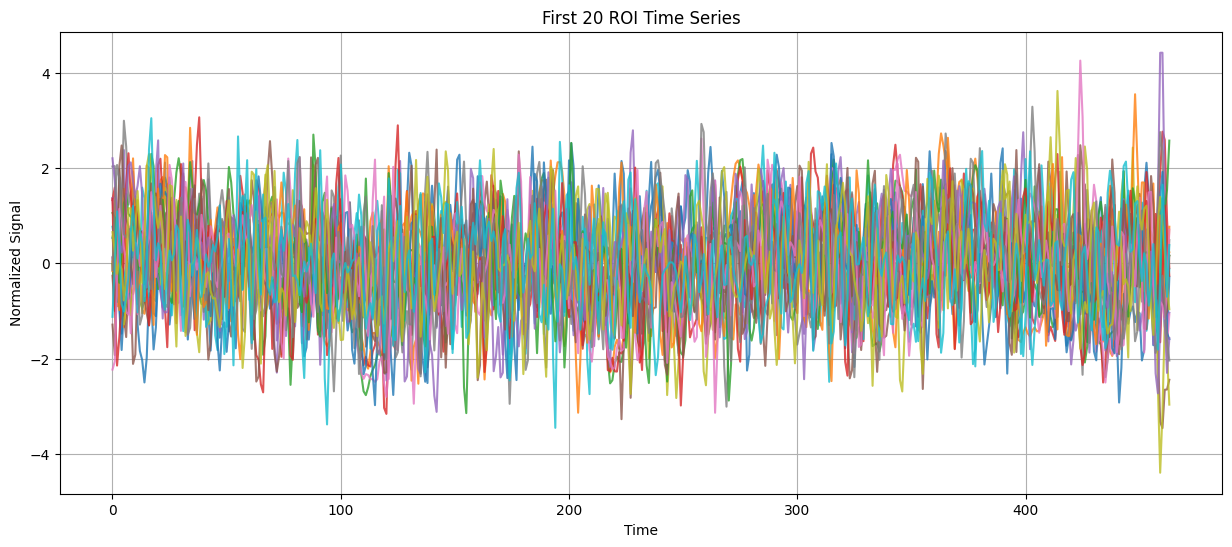

In [24]:
import matplotlib.pyplot as plt
import numpy as np

sample = np.load(files[0])

plt.figure(figsize=(15,6))

for i in range(20):
    plt.plot(sample[:, i], alpha=0.8)

plt.title("First 20 ROI Time Series")
plt.xlabel("Time")
plt.ylabel("Normalized Signal")
plt.grid(True)

plt.show()

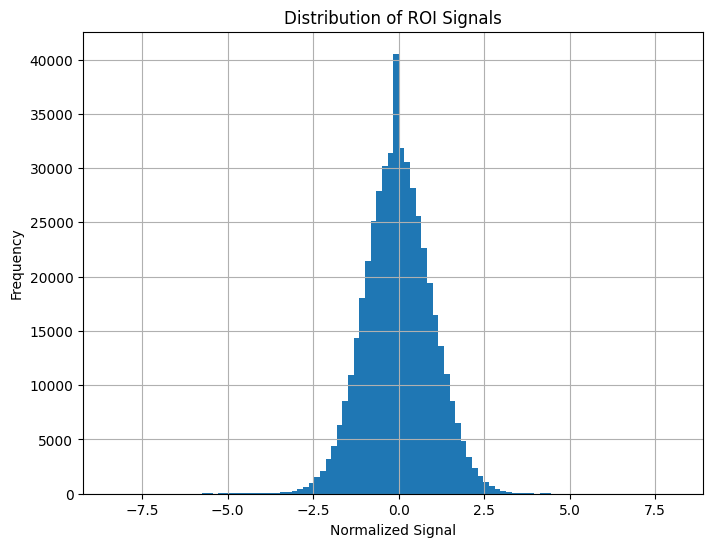

In [26]:
plt.figure(figsize=(8,6))

plt.hist(
    sample.flatten(),
    bins=100
)

plt.title("Distribution of ROI Signals")

plt.xlabel("Normalized Signal")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [27]:
parcel_counts = []

for f in files:
    parcel_counts.append(
        np.load(f).shape[1]
    )

print("Unique parcel counts:")

print(np.unique(parcel_counts))

Unique parcel counts:
[1032]
